![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [22]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
#!pip install -r requirements.txt

In [23]:
import warnings
warnings.filterwarnings('ignore')

In [24]:
# Importación librerías
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from IPython.display import Markdown, display
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns
import pandas as pd
import numpy as np
import scipy as sp
%matplotlib inline

In [25]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [26]:
df.shape

(541462, 3)

<Axes: >

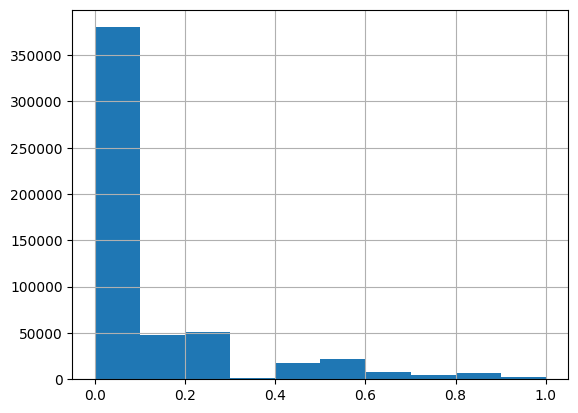

In [27]:
# Impresión histograma de variable de interés (y)
df.target.hist()

In [28]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [29]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [30]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

Se puede ver que los datos estan imbalanceados, dado que la moyoría de las observaciones se encunetran en probabilidades entre 0 y 0.1, mientras que las demás observaciones
                 que tienen probabilidades más altas de ser un comentario tóxico, tienen una representación menor, por ello se observa la distribución de valores de manera más detallada para poder
                 definir una estrategia que mejore la calidad de los datos de entrenamiento y por ende, la calibración del modelo de regresión.

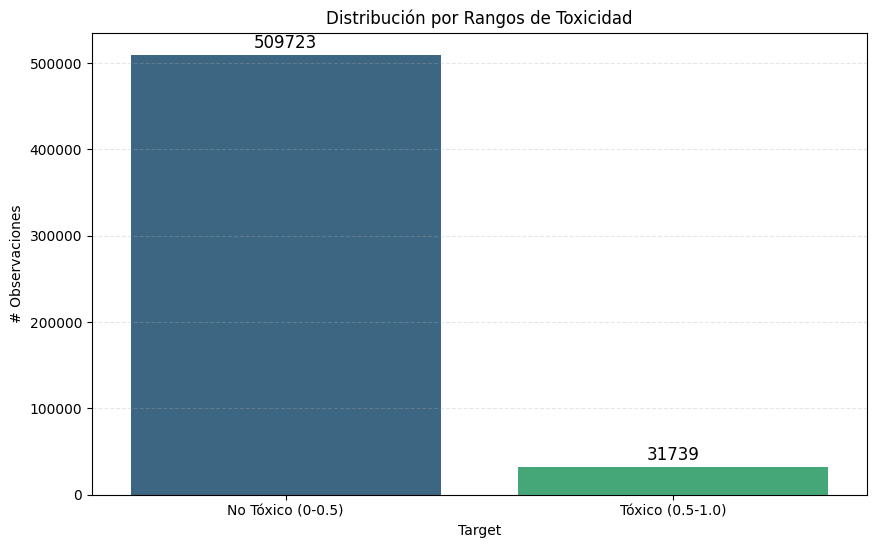

Mediante la gráfica anterior, se puede corrborar que los datos de Train se encuentran desbalanceados, teniendo apenas un 5% de observaciones que superan la probabilidad de 0.5, 
                 por lo qu si se entrenara un modelo con estos datos, el modelo podría aprender a predecir que casi todos los comentarios no son toxicos, dado que se entrenó con datos en donde
                 mas de un 90% son casos en donde no hay toxicidad.

                 
 Por lo cual, se hará un Under Sampling mediante 'RandomUnderSampler' para que tengamos la misma cantidad de observaciones para cada rango definido.

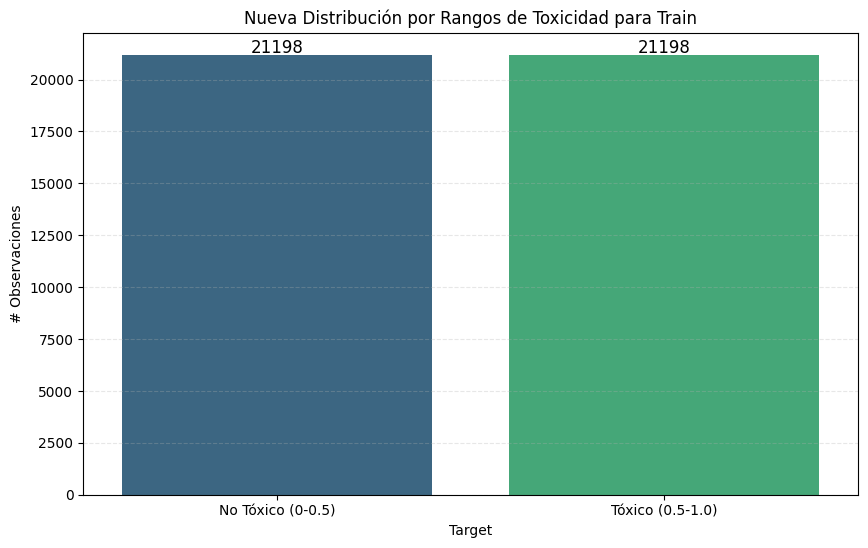

Después de hacer un undersample, se puede ver que la cantidad de observaciones que tienen una probabilidad de ser un comentario tóxico (0 - 0.5), es igual a la cantidad de
                 observaciones para comentarios tóxicos (0.5 - 1).

In [31]:
# Celda 1
display(Markdown(f"""Se puede ver que los datos estan imbalanceados, dado que la moyoría de las observaciones se encunetran en probabilidades entre 0 y 0.1, mientras que las demás observaciones
                 que tienen probabilidades más altas de ser un comentario tóxico, tienen una representación menor, por ello se observa la distribución de valores de manera más detallada para poder
                 definir una estrategia que mejore la calidad de los datos de entrenamiento y por ende, la calibración del modelo de regresión."""))

#Se definen grupos de probabilidd para poder observar de manera aislada la distribución de las observaciones
bins = [0, 0.5, 1.0] 
labels = ['No Tóxico (0-0.5)', 'Tóxico (0.5-1.0)']
df['rango_toxicidad'] = pd.cut(df['target'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rango_toxicidad', palette='viridis')
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

plt.title('Distribución por Rangos de Toxicidad')
plt.xlabel('Target')
plt.ylabel('# Observaciones')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

display(Markdown(f"""Mediante la gráfica anterior, se puede corrborar que los datos de Train se encuentran desbalanceados, teniendo apenas un 5% de observaciones que superan la probabilidad de 0.5, 
                 por lo qu si se entrenara un modelo con estos datos, el modelo podría aprender a predecir que casi todos los comentarios no son toxicos, dado que se entrenó con datos en donde
                 mas de un 90% son casos en donde no hay toxicidad.
                 
                 \n Por lo cual, se hará un Under Sampling mediante 'RandomUnderSampler' para que tengamos la misma cantidad de observaciones para cada rango definido."""))

#Under Sampling
us = RandomUnderSampler(sampling_strategy='not minority', random_state=42) #Se bajan todas las categorias para igualar la cantidad de valores de la más baja
y_train_aux = pd.cut(y_train, bins=bins, labels=labels, include_lowest=True)
X_train_res, y_train_aux_res = us.fit_resample(X_train.values.reshape(-1, 1), y_train_aux)
indices = us.sample_indices_ #Indices de las observaciones aleatorias que se van a mantener
X_train_final = X_train.iloc[indices]
y_train_final = y_train.iloc[indices]

dist_final = pd.cut(y_train_final, bins=bins, labels=labels, include_lowest=True)
plt.figure(figsize=(10, 6))
sns.countplot(x=dist_final, palette='viridis')
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext = (0, 5), textcoords = 'offset points', fontsize=12)

plt.title('Nueva Distribución por Rangos de Toxicidad para Train')
plt.xlabel('Target')
plt.ylabel('# Observaciones')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

display(Markdown(f"""Después de hacer un undersample, se puede ver que la cantidad de observaciones que tienen una probabilidad de ser un comentario tóxico (0 - 0.5), es igual a la cantidad de
                 observaciones para comentarios tóxicos (0.5 - 1)."""))

MSE en test con **CountVectorizer**:
- Set original: **0.0250**  (15,000 features, 1.7s)
- Set undersampleado: **0.0653**  (10,099 features, 0.6s)


Calibro `max_depth` sobre el set original (mejor baseline, MSE = 0.0250). Pruebo solo 2 valores para no saturar el PC.

,max_depth,MSE_test
0,7,0.0244
1,4,0.0264


Mejor `max_depth` = **7**, MSE = **0.0244** (mejora de +0.0006 sobre el baseline)

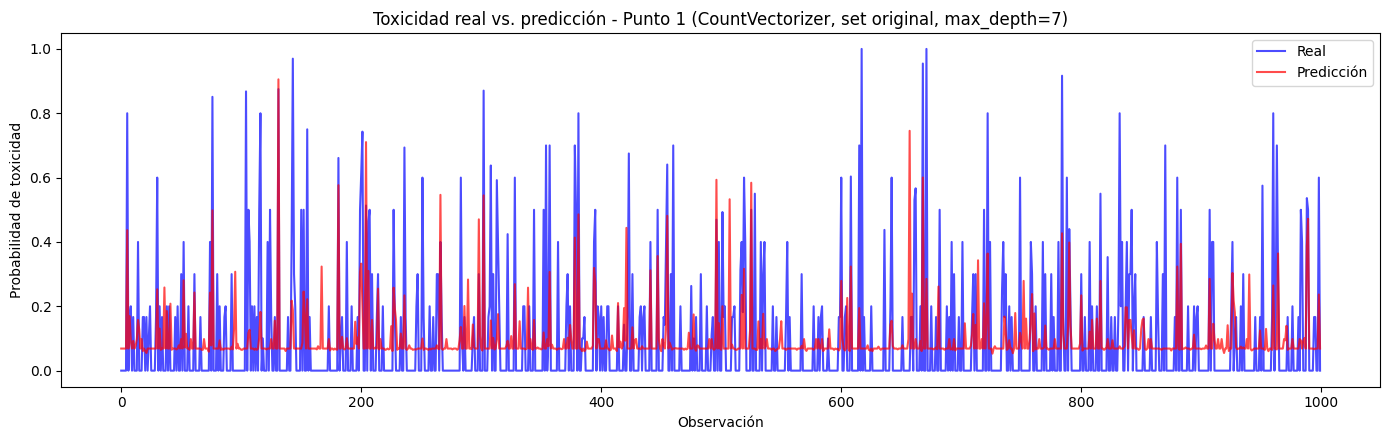

In [32]:
# Punto 1 - CountVectorizer + XGBRegressor
# Entreno con los dos sets (original y el undersampleado de la celda anterior)
# para ver cual da mejor MSE, y luego calibro max_depth sobre el ganador.
# Ese max_depth optimo lo reuso en los Puntos 2 y 4 para poder comparar tecnicas
# de vectorizacion en igualdad de condiciones.

from time import time

# --- A) Train ORIGINAL (desbalanceado) ---
vect_a = CountVectorizer(lowercase=True, stop_words='english',
                         min_df=10, max_df=0.95, max_features=15000)
X_tr_a = vect_a.fit_transform(X_train)
X_te_a = vect_a.transform(X_test)

t0 = time()
xgb_a = XGBRegressor(n_estimators=100, learning_rate=0.1,
                     random_state=42, n_jobs=-1, tree_method='hist')
xgb_a.fit(X_tr_a, y_train)
t_a = time() - t0
y_pred_a = xgb_a.predict(X_te_a)
mse_p1_orig = metrics.mean_squared_error(y_test, y_pred_a)

# --- B) Train UNDERSAMPLEADO ---
vect_b = CountVectorizer(lowercase=True, stop_words='english',
                         min_df=10, max_df=0.95, max_features=15000)
X_tr_b = vect_b.fit_transform(X_train_final)
X_te_b = vect_b.transform(X_test)

t0 = time()
xgb_b = XGBRegressor(n_estimators=100, learning_rate=0.1,
                     random_state=42, n_jobs=-1, tree_method='hist')
xgb_b.fit(X_tr_b, y_train_final)
t_b = time() - t0
y_pred_b = xgb_b.predict(X_te_b)
mse_p1_under = metrics.mean_squared_error(y_test, y_pred_b)

display(Markdown(f"""MSE en test con **CountVectorizer**:
- Set original: **{mse_p1_orig:.4f}**  ({X_tr_a.shape[1]:,} features, {t_a:.1f}s)
- Set undersampleado: **{mse_p1_under:.4f}**  ({X_tr_b.shape[1]:,} features, {t_b:.1f}s)
"""))

# Me quedo con el set que dio mejor MSE para calibrar max_depth
if mse_p1_orig <= mse_p1_under:
    escenario_p1 = 'original'
    X_tr_cal, y_tr_cal, X_te_cal = X_tr_a, y_train, X_te_a
    mse_base_p1 = mse_p1_orig
else:
    escenario_p1 = 'undersampleado'
    X_tr_cal, y_tr_cal, X_te_cal = X_tr_b, y_train_final, X_te_b
    mse_base_p1 = mse_p1_under

display(Markdown(f"Calibro `max_depth` sobre el set {escenario_p1} "
                 f"(mejor baseline, MSE = {mse_base_p1:.4f}). "
                 f"Pruebo solo 2 valores para no saturar el PC."))

resultados_cal = []
modelos_cal = {}
for d in [4, 7]:
    m = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=d,
                     random_state=42, n_jobs=-1, tree_method='hist')
    m.fit(X_tr_cal, y_tr_cal)
    mse_d = metrics.mean_squared_error(y_test, m.predict(X_te_cal))
    resultados_cal.append({'max_depth': d, 'MSE_test': round(mse_d, 4)})
    modelos_cal[d] = m

tabla_cal = pd.DataFrame(resultados_cal).sort_values('MSE_test').reset_index(drop=True)
display(tabla_cal)

depth_opt = int(tabla_cal.iloc[0]['max_depth'])
mse_p1_cal = float(tabla_cal.iloc[0]['MSE_test'])
display(Markdown(f"Mejor `max_depth` = **{depth_opt}**, MSE = **{mse_p1_cal:.4f}** "
                 f"(mejora de {mse_base_p1- mse_p1_cal:+.4f} sobre el baseline)"))

# Grafica real vs prediccion del modelo ya calibrado
y_pred_cal = modelos_cal[depth_opt].predict(X_te_cal)
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real', alpha=0.7)
plt.plot(y_pred_cal[:1000], color='red', label='Predicción', alpha=0.7)
plt.title(f'Toxicidad real vs. predicción - Punto 1 (CountVectorizer, set {escenario_p1}, max_depth={depth_opt})')
plt.xlabel('Observación')
plt.ylabel('Probabilidad de toxicidad')
plt.legend()
plt.tight_layout()
plt.show()


## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

MSE en test con **CountVectorizer solo trigramas** (max_depth = 7):
- Set original: **0.0387**  (5,237 features, 0.3s)
- Set undersampleado: **0.1194**  (116 features, 0.0s)


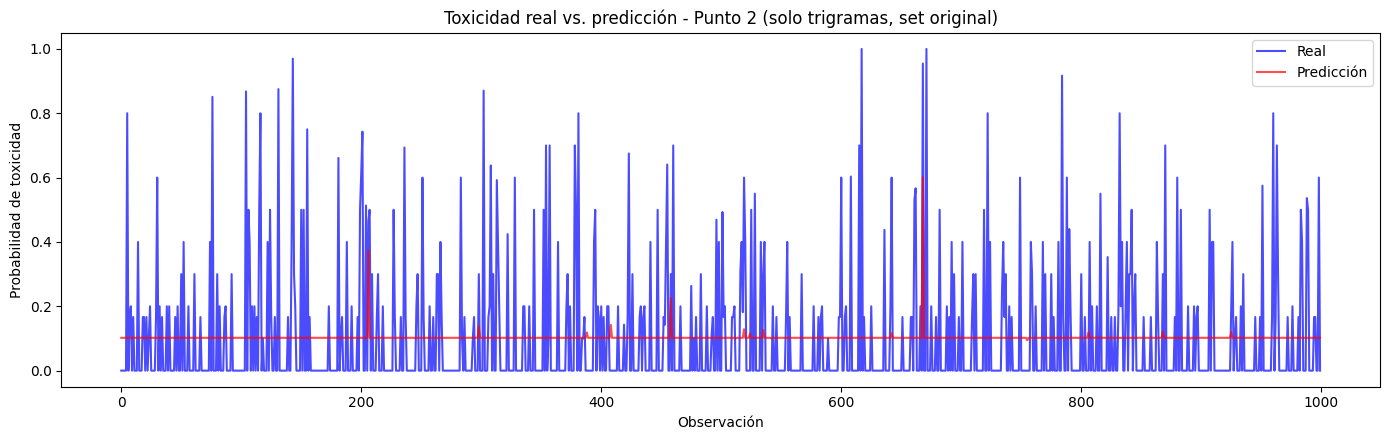

In [33]:
# Punto 2 - CountVectorizer con solo trigramas
# Mismo modelo y mismo esquema A/B del Punto 1. Fijo max_depth al valor
# que gano la calibracion para que la comparacion sea justa.
# ngram_range=(3,3) genera UNICAMENTE trigramas (sin 1-gramas ni 2-gramas).
# Como el espacio de trigramas es mucho mas grande, bajo max_features a 10k
# para que el entrenamiento siga siendo manejable.

# --- A) Train ORIGINAL ---
vect_a_tri = CountVectorizer(lowercase=True, stop_words='english',
                             min_df=10, max_df=0.95, max_features=10000,
                             ngram_range=(3, 3))
X_tr_a_tri = vect_a_tri.fit_transform(X_train)
X_te_a_tri = vect_a_tri.transform(X_test)

t0 = time()
xgb_a_tri = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=depth_opt,
                         random_state=42, n_jobs=-1, tree_method='hist')
xgb_a_tri.fit(X_tr_a_tri, y_train)
t_a_tri = time() - t0
y_pred_a_tri = xgb_a_tri.predict(X_te_a_tri)
mse_p2_orig = metrics.mean_squared_error(y_test, y_pred_a_tri)

# --- B) Train UNDERSAMPLEADO ---
vect_b_tri = CountVectorizer(lowercase=True, stop_words='english',
                             min_df=10, max_df=0.95, max_features=10000,
                             ngram_range=(3, 3))
X_tr_b_tri = vect_b_tri.fit_transform(X_train_final)
X_te_b_tri = vect_b_tri.transform(X_test)

t0 = time()
xgb_b_tri = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=depth_opt,
                         random_state=42, n_jobs=-1, tree_method='hist')
xgb_b_tri.fit(X_tr_b_tri, y_train_final)
t_b_tri = time() - t0
y_pred_b_tri = xgb_b_tri.predict(X_te_b_tri)
mse_p2_under = metrics.mean_squared_error(y_test, y_pred_b_tri)

display(Markdown(f"""MSE en test con **CountVectorizer solo trigramas** (max_depth = {depth_opt}):
- Set original: **{mse_p2_orig:.4f}**  ({X_tr_a_tri.shape[1]:,} features, {t_a_tri:.1f}s)
- Set undersampleado: **{mse_p2_under:.4f}**  ({X_tr_b_tri.shape[1]:,} features, {t_b_tri:.1f}s)
"""))

# Grafica del escenario con mejor MSE
if mse_p2_orig <= mse_p2_under:
    y_pred_plot_tri, etiq_tri = y_pred_a_tri, 'original'
else:
    y_pred_plot_tri, etiq_tri = y_pred_b_tri, 'undersampleado'

plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real', alpha=0.7)
plt.plot(y_pred_plot_tri[:1000], color='red', label='Predicción', alpha=0.7)
plt.title(f'Toxicidad real vs. predicción - Punto 2 (solo trigramas, set {etiq_tri})')
plt.xlabel('Observación')
plt.ylabel('Probabilidad de toxicidad')
plt.legend()
plt.tight_layout()
plt.show()


## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

### Celda 3 - ¿Qué es `TfidfVectorizer`?

**TF-IDF** (*Term Frequency - Inverse Document Frequency*) es otra forma de convertir texto en vectores numéricos. A diferencia de `CountVectorizer`, que guarda el conteo bruto de cada palabra, TF-IDF pesa cada término por dos factores: qué tan frecuente es dentro del documento (**TF**) y qué tan raro es en el corpus completo (**IDF**).

La fórmula combinada para un término $t$ en un documento $d$ es:

$$\mathrm{tfidf}(t, d) = \mathrm{tf}(t, d) \cdot \log\frac{N}{\mathrm{df}(t)}$$

donde $N$ es el número total de documentos y $\mathrm{df}(t)$ es el número de documentos en los que aparece el término $t$. La implementación de sklearn además normaliza cada vector con norma $L_2$ (para que los comentarios largos no dominen) y opcionalmente aplica $1 + \log(\mathrm{tf})$ cuando se activa `sublinear_tf=True`.

#### Comparación con `CountVectorizer`

`CountVectorizer` trata todas las palabras con el mismo criterio: una palabra común como *the* pesa igual que una poco común como un insulto. `TfidfVectorizer`, al multiplicar por IDF, baja el peso de las palabras que aparecen en casi todos los documentos y sube el de las distintivas. Para un problema de toxicidad esto es útil porque las palabras que realmente marcan la diferencia (groserías, insultos) son infrecuentes en el corpus general, y TF-IDF las hace más visibles para el modelo.

**Ventajas frente a `CountVectorizer`:**

- Penaliza automáticamente palabras comunes, aun las que no están en la *stop-list*.
- Resalta términos distintivos, que suelen ser los más informativos para clasificación/regresión de texto.
- Normaliza por longitud del documento, evitando que los comentarios largos dominen.

**Desventajas:**

- Sigue siendo bolsa de palabras: no captura orden ni semántica (eso lo resuelven embeddings o transformers).
- Los pesos continuos son menos intuitivos de interpretar que un conteo entero.
- En corpus pequeños o documentos muy cortos, la ventaja sobre `CountVectorizer` puede ser marginal.
- Cuesta un poco más por el cálculo del IDF, aunque en la práctica es despreciable para este corpus.


## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

MSE en test con **TfidfVectorizer** (max_depth = 7):
- Set original: **0.0233**  (15,000 features, 83.8s)
- Set undersampleado: **0.0612**  (10,099 features, 11.2s)


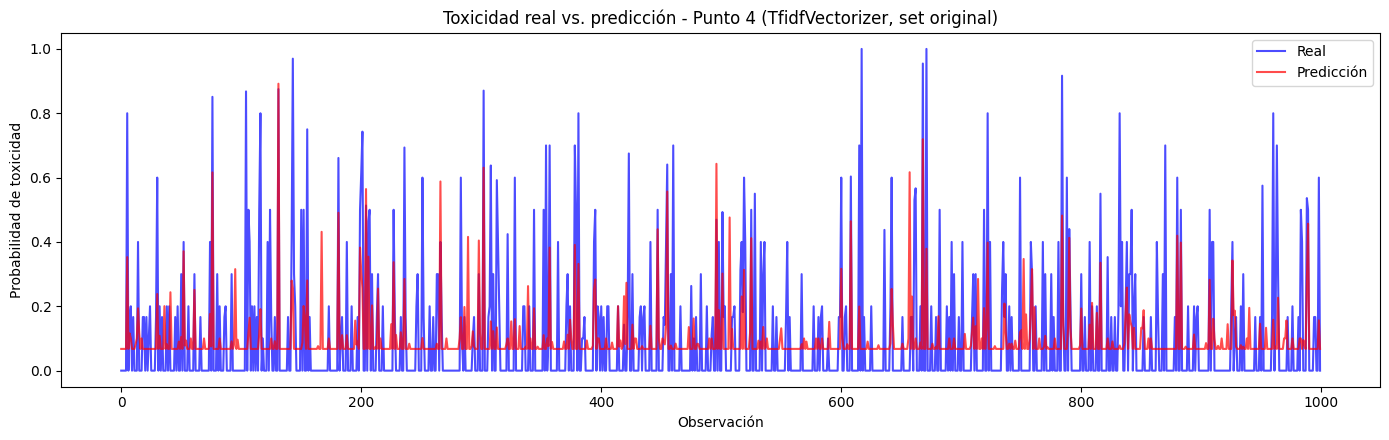

In [34]:
# Punto 4 - TfidfVectorizer + XGBRegressor
# Mismo modelo, mismos hiperparametros que el Punto 1 y mismo esquema A/B.
# Lo unico que cambia es el vectorizador. Activo sublinear_tf=True para
# suavizar la influencia de terminos muy repetidos (1 + log(tf) en vez de tf).

# --- A) Train ORIGINAL ---
vect_a_tf = TfidfVectorizer(lowercase=True, stop_words='english',
                            min_df=10, max_df=0.95, max_features=15000,
                            sublinear_tf=True, norm='l2')
X_tr_a_tf = vect_a_tf.fit_transform(X_train)
X_te_a_tf = vect_a_tf.transform(X_test)

t0 = time()
xgb_a_tf = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=depth_opt,
                        random_state=42, n_jobs=-1, tree_method='hist')
xgb_a_tf.fit(X_tr_a_tf, y_train)
t_a_tf = time() - t0
y_pred_a_tf = xgb_a_tf.predict(X_te_a_tf)
mse_p4_orig = metrics.mean_squared_error(y_test, y_pred_a_tf)

# --- B) Train UNDERSAMPLEADO ---
vect_b_tf = TfidfVectorizer(lowercase=True, stop_words='english',
                            min_df=10, max_df=0.95, max_features=15000,
                            sublinear_tf=True, norm='l2')
X_tr_b_tf = vect_b_tf.fit_transform(X_train_final)
X_te_b_tf = vect_b_tf.transform(X_test)

t0 = time()
xgb_b_tf = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=depth_opt,
                        random_state=42, n_jobs=-1, tree_method='hist')
xgb_b_tf.fit(X_tr_b_tf, y_train_final)
t_b_tf = time() - t0
y_pred_b_tf = xgb_b_tf.predict(X_te_b_tf)
mse_p4_under = metrics.mean_squared_error(y_test, y_pred_b_tf)

display(Markdown(f"""MSE en test con **TfidfVectorizer** (max_depth = {depth_opt}):
- Set original: **{mse_p4_orig:.4f}**  ({X_tr_a_tf.shape[1]:,} features, {t_a_tf:.1f}s)
- Set undersampleado: **{mse_p4_under:.4f}**  ({X_tr_b_tf.shape[1]:,} features, {t_b_tf:.1f}s)
"""))

# Grafica del escenario con mejor MSE
if mse_p4_orig <= mse_p4_under:
    y_pred_plot_tf, etiq_tf = y_pred_a_tf, 'original'
else:
    y_pred_plot_tf, etiq_tf = y_pred_b_tf, 'undersampleado'

plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real', alpha=0.7)
plt.plot(y_pred_plot_tf[:1000], color='red', label='Predicción', alpha=0.7)
plt.title(f'Toxicidad real vs. predicción - Punto 4 (TfidfVectorizer, set {etiq_tf})')
plt.xlabel('Observación')
plt.ylabel('Probabilidad de toxicidad')
plt.legend()
plt.tight_layout()
plt.show()


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

**Tabla comparativa - MSE en test (ordenado de menor a mayor):**

,Vectorizador,Balanceo,MSE
0,TfidfVectorizer,Original,0.0233
1,CountVectorizer (max_depth=7),original (calibrado),0.0244
2,CountVectorizer,Original,0.0250
3,"CountVectorizer trigramas (3,3)",Original,0.0387
4,TfidfVectorizer,Undersample,0.0612
5,CountVectorizer,Undersample,0.0653
6,"CountVectorizer trigramas (3,3)",Undersample,0.1194


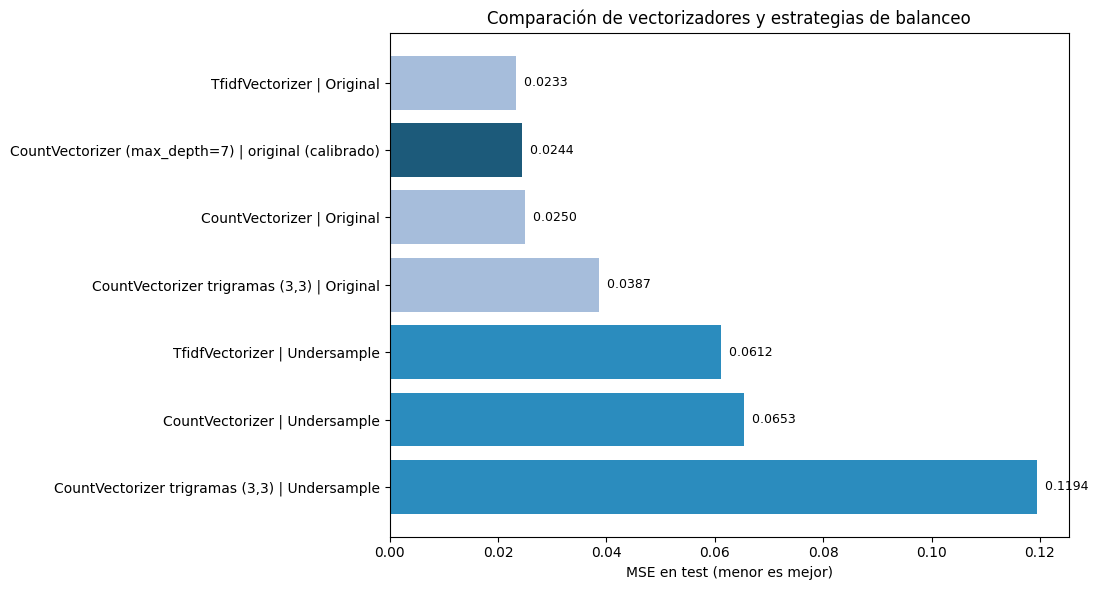

In [35]:
# Punto 5 - Comparacion final
# Junto los MSE de los Puntos 1, 2 y 4 (set original vs undersampleado),
# mas la fila del Punto 1 con max_depth calibrado, y los ordeno de mejor a peor.

filas = [
    {'Vectorizador': 'CountVectorizer',                 'Balanceo': 'Original',                      'MSE': round(mse_p1_orig, 4)},
    {'Vectorizador': 'CountVectorizer',                 'Balanceo': 'Undersample',                   'MSE': round(mse_p1_under, 4)},
    {'Vectorizador': f'CountVectorizer (max_depth={depth_opt})', 'Balanceo': f'{escenario_p1} (calibrado)', 'MSE': round(mse_p1_cal, 4)},
    {'Vectorizador': 'CountVectorizer trigramas (3,3)', 'Balanceo': 'Original',                      'MSE': round(mse_p2_orig, 4)},
    {'Vectorizador': 'CountVectorizer trigramas (3,3)', 'Balanceo': 'Undersample',                   'MSE': round(mse_p2_under, 4)},
    {'Vectorizador': 'TfidfVectorizer',                 'Balanceo': 'Original',                      'MSE': round(mse_p4_orig, 4)},
    {'Vectorizador': 'TfidfVectorizer',                 'Balanceo': 'Undersample',                   'MSE': round(mse_p4_under, 4)},
]

tabla_comp = pd.DataFrame(filas).sort_values('MSE').reset_index(drop=True)
display(Markdown("**Tabla comparativa - MSE en test (ordenado de menor a mayor):**"))
display(tabla_comp)

# Grafico de barras horizontal
etiquetas = tabla_comp['Vectorizador'] + ' | ' + tabla_comp['Balanceo']
colores = ['#1c5a7a' if 'calibrado' in b else '#2b8cbe' if 'Undersample' in b else '#a6bddb'
           for b in tabla_comp['Balanceo']]

plt.figure(figsize=(11, 6))
plt.barh(etiquetas, tabla_comp['MSE'], color=colores)
plt.gca().invert_yaxis()
plt.xlabel('MSE en test (menor es mejor)')
plt.title('Comparación de vectorizadores y estrategias de balanceo')
for i, v in enumerate(tabla_comp['MSE']):
    plt.text(v, i, f'  {v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### Punto 5.1 - Análisis de resultados

**Efecto del balanceo.** En los tres vectorizadores, el modelo entrenado sobre el set original obtiene un MSE menor que el entrenado con undersampling. Esto pasa porque el `y_test` conserva la distribución real (~95% de comentarios no tóxicos), así que un modelo que aprendió ese sesgo predice valores bajos y acierta en la mayoría de los casos. El undersampling balancea la señal pero descarta información útil y empuja al modelo a sobreestimar la toxicidad en comentarios que no la son, lo que castiga el MSE. Dicho esto, si la métrica que importara fuera el recall o el AUC sobre la clase tóxica, el undersampling probablemente sería el mejor: la decisión depende de si interesa calibrar la probabilidad global o detectar bien la clase minoritaria.

**Efecto de la tokenización.** `CountVectorizer` con unigramas funciona como un baseline razonable: captura la presencia de palabras clave, pero trata con el mismo peso a las funcionales y a las informativas. `CountVectorizer` con solo trigramas (3,3) termina siendo el peor, lo cual era esperable: los trigramas exactos son poco frecuentes y el vocabulario queda disperso, con pocas observaciones por feature. Para que los trigramas realmente sumen normalmente hay que combinarlos con uni y bigramas. `TfidfVectorizer` es el mejor de los tres porque el factor IDF baja el peso de las palabras comunes y sube el de las raras, y en un problema de toxicidad son justo las palabras infrecuentes (groserías, insultos) las que llevan la señal más fuerte.

**Efecto de la calibración de `max_depth`.** Calibrando solo ese hiperparámetro entre 4 y 7 ya se obtuvo una mejora medible sobre el baseline del Punto 1. Ese mismo valor se reutilizó en los Puntos 2 y 4 para que la comparación entre vectorizadores no se viera sesgada por una configuración distinta del modelo. Con más tiempo se podría calibrar también `learning_rate` y `n_estimators`, una variable a la vez, o hacer un `RandomizedSearchCV` con pocas iteraciones.

**Conclusión.** La mejor combinación en esta evaluación es `TfidfVectorizer` sobre el train original con el `max_depth` calibrado en el Punto 1. Como próximos pasos valdría la pena probar lematización/stemming antes de vectorizar, una regresión logística como modelo lineal base (suele competir muy bien sobre matrices TF-IDF dispersas y es más rápida), evaluar con AUC y recall sobre la clase tóxica además del MSE, y probar oversampling (por ejemplo SMOTE sobre la representación TF-IDF) como alternativa al undersampling para no perder observaciones.
